# **ONE RETAIL II**

In this project, we take on the role of a data scientist working for an online retail company. The main objective is to identify which customers are more likely to make repeat purchases.

This prediction will allow the business to design targeted strategies:
- **Loyalty actions** for customers with a high probability of returning.
- **Retention actions** for customers with a low probability of purchasing again.

The dataset contains historical transaction data, and our goal is to build a machine learning model that can estimate the likelihood of a customer making a future purchase.



## **The Dataset**

The dataset contains all transactions made by a UK-based online retail company between **December 1, 2009 and December 9, 2011**. The company sells unique gift items, and many of its customers are wholesalers.

**Columns:**

- **Invoice**: Unique identifier for each transaction. If the value starts with **"C"**, it indicates a **cancellation**.

- **StockCode**: Unique item code.

- **Description**: Name of the product.

- **Quantity**: Number of units of the product purchased in a transaction.

- **InvoiceDate**: Date and time when the transaction occurred.

- **Price**: Price per unit of the product (in GBP).

- **Customer ID**: Unique identifier for each customer.

- **Country**: Country where the customer is located.

## **Libraries**

In [1]:
import sys
sys.path.append('../src')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cleaning
import visualizations

## **EDA**
### **Data Loading**

- Frist the data is loaded via `pandas` function `.read_excel`, specifying that all sheets will be loaded as a dataframe, creating this way a **dataframe of dataframes**.
- To handle all the **EDA** steps in a cohesive way, the next step is to **concatenate** both dataframes in a single one.
- Finally the concatenated dataframe is displayed to make sure all steps have been executed properly and the **missing values per column** are visualized.

In [2]:
path = "../datasets/online_retail_II.xlsx"

# Read both sheets (all sheets) at once
dfs = pd.read_excel(path, sheet_name=None, verbose=True)

# Concatenate into one DataFrame
df = pd.concat(dfs.values(), ignore_index=True)
display(df.head(10))

Reading sheet Year 2009-2010
Reading sheet Year 2010-2011


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


### **Cleaning**

With the `.info()` function, the following information  about the dataset can be observed:
- Size: Number of Rows x Number of Columns
- Datatypes of each column: Here is easy to spot if there's some wrong datatype
- Missing Values (The `isna().sum()` functions are used eitherway to visualize better the missing values per column)
- Memory usage of the dataframe

In [3]:
print(df.info())
print(f"\nMissing Values per Column:\n{df.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
None

Missing Values per Column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


By observing the `.info()` output, the next issues need to be adressed:
- Datatypes: 
    - Invoice: Should be `int`, nevertheless, some instances may have the letter **C**, indicating **cancelled invoice**. To adress this, a new column will be created, indicating with 0 the non cancellations and with 1 the cancellations. This way enabling the removal of all **C's** of the invoice columns allowing the casting to `int`.
- Missing Values: 4382 in **Description** column (Name of the product) and 243007 in **Customer ID** (Large amount considering the dataset has 1067371 entries)

In [4]:
# A copy of the original dataframe is made to not mess with the original data (Although in a real wolrd dscenario we must be cautious when copying large datasets like this one)
df_copy = df.copy()

#### **Datatypes**
**Invoice**

- By identifying which invoices had been cancelled, a new column ``Cancellation {0: Not cancelled, 1: Cancelled}`` is created.
    - Usually the creation of columns (feature engineering) is done after the cleaning process, however, in this case, since it was affecting directly to a column's datatype, the creation of this new column at such early stage has been considered as the optimal aproach.
- Then all **C's** from the invoice column are deleted and then the column is cated into `int` datatype.

First, we search those **Invoice codes** that are not one of the following patterns:
- XXXXX...X, where X is any digit from 1 to 9
- CXXXX...X, same but adding the **C** for **cancellation**.

In [5]:
invoice_pattern = df_copy["Invoice"].astype(str).str.match(r"C?\d+")
df_copy[~invoice_pattern]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


The previous 6 intances didn't match the patterns mentioned, moreover **Customer ID** is `NaN` and the **Description** is definitely not a product's name.\
The best approach here would be to call our client or spoke to someone in our team that knows why those instances are the way they are.\
 However, in this situation we cannot ask anybody, so the best aproach will be to just delete those instances.

In [6]:
# Delete previous instances
df_copy = df_copy[invoice_pattern]

# Create Cancellation column
df_copy["Cancellation"] = df_copy["Invoice"].astype(str).str.startswith("C").astype(int)

# Remove "C" from Invoice and convert to integer
df_copy["Invoice"] = df_copy["Invoice"].astype(str).str.replace("C", "", regex=False)
df_copy["Invoice"] = df_copy["Invoice"].astype(int)

# Check result
display(df_copy[df_copy["Cancellation"] == 1].head(20))
print(df_copy["Invoice"].dtype)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
178,489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
179,489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,1
180,489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,1
181,489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,1
182,489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
183,489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
184,489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
185,489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,1
186,489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
196,489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,1


int32


#### **Missing Values**

**Description & Customer ID**

Without the **Customer_ID** there's no way we can answer whether if that customer is likely to buy again or not. Even though the number of missing IDs is very large, there's no extra information that helps the inputation of those values, so the best approach will be to delete those instances.

In [7]:
df_copy = df_copy.dropna(subset="Customer ID")
df_copy["Customer ID"] = df_copy["Customer ID"].astype(int)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       824364 non-null  int32         
 1   StockCode     824364 non-null  object        
 2   Description   824364 non-null  object        
 3   Quantity      824364 non-null  int64         
 4   InvoiceDate   824364 non-null  datetime64[ns]
 5   Price         824364 non-null  float64       
 6   Customer ID   824364 non-null  int32         
 7   Country       824364 non-null  object        
 8   Cancellation  824364 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(3)
memory usage: 53.5+ MB


Luckily, the missing values in the **Description** column where also related with some of the missing **IDs**. In case there was some missing value on the **Description** column, before labeling the missing product name as **NO DESCRIPTION** or something similar, each **StockCode** of the missing value should be searched to see if the product's name exist in another invoice or not.

#### **Duplicated**

To treat the duplicates, we must assume that, two identical instances (all values in the columns are the same) correspond to a input mistake. Since there is not, a priori, an explanation on why a client will purchase the same quantity of the same product, at the same time in the same invoice but register it as another product instead of adding the quantity to one of the instances.
- Working under this assumption, all duplicated instances will be removed.

In [8]:
df_copy = df_copy.drop_duplicates()
df_copy.duplicated().sum()

0

#### **Impossible Values**

To end the cleaning stage, the existence of impossible values or writing typos must be adressed.

##### **Categorical Columns**

- **StockCode**

In [9]:
df_copy[~df_copy["StockCode"].astype(str).str.match(r"^[A-Z\d]+$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
18410,490943,BANK CHARGES,Bank Charges,-1,2009-12-08 14:08:00,15.0,16703,United Kingdom,1
18466,490948,BANK CHARGES,Bank Charges,1,2009-12-08 14:29:00,15.0,16805,United Kingdom,0
94431,498269,BANK CHARGES,Bank Charges,1,2010-02-17 15:03:00,15.0,16928,United Kingdom,0
148098,503497,BANK CHARGES,Bank Charges,1,2010-04-01 12:07:00,15.0,17539,United Kingdom,0
149063,503571,BANK CHARGES,Bank Charges,-1,2010-04-01 15:45:00,15.0,17539,United Kingdom,1


By searching those **StockCodes** that doesn't contain Numbers or capital letters, we've found that not all Products are actually items, as we can see in these **Bank Charges** instnaces.

- **Description**

In [10]:
df_copy[~df_copy["Description"].astype(str).str.match(r"^[A-Z\s\d\-\+\'\&\"\/\,\.\!\(\)]+$")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
361,489517,21705,BAG 500g SWIRLY MARBLES,1,2009-12-01 11:34:00,1.65,16329,United Kingdom,0
618,489526,46000S,POLYESTER FILLER PAD 40x40cm,2,2009-12-01 11:50:00,1.45,12533,Germany,0
619,489526,20964,POLYESTER FILLER PAD 60x40cm,3,2009-12-01 11:50:00,2.55,12533,Germany,0
735,489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299,United Kingdom,1
736,489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
1065620,581469,21704,BAG 250g SWIRLY MARBLES,1,2011-12-08 19:28:00,0.85,14606,United Kingdom,0
1065742,581475,21705,BAG 500g SWIRLY MARBLES,24,2011-12-09 08:39:00,0.39,13069,United Kingdom,0
1067002,581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,1
1067073,581514,21705,BAG 500g SWIRLY MARBLES,84,2011-12-09 11:20:00,0.39,17754,United Kingdom,0


Here we searched for strange product names, even though no writting typo has been found, now we know, corroborating with the previous cell, that not all instances correspond to actual prodcuts, as it can be seen in the **Discount** and **Manual** instnaces.

Finally, a check in the **Country** column is done, to make sure no typos are found.
- **Country**

In [11]:
df_copy["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Netherlands', 'Poland',
       'Spain', 'Channel Islands', 'Italy', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland',
       'Switzerland', 'Unspecified', 'Nigeria', 'Malta', 'RSA',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

##### **Numerical Columns**

Using the `.describe()` method, impossible numerical values or outliers can be easily spotted. Comparing the **min or max** value with the **mean or median** value of the column.

In [12]:
df_copy.describe()

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Cancellation
count,797885.000000,797885.000000,797885,797885.000000,797885.000000,797885.000000
mean,537364.043833,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777,0.023048
min,489434.000000,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000,0.000000
25%,514374.000000,2.000000,2010-07-02 09:47:00,1.250000,13964.000000,0.000000
50%,536707.000000,5.000000,2010-12-02 12:33:00,1.950000,15228.000000,0.000000
75%,561902.000000,12.000000,2011-07-31 15:50:00,3.750000,16788.000000,0.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,1.000000
std,26906.673792,191.670371,NaN,71.392549,1696.466663,0.150057


Thanks to this table, some unusual values can be easily spotted:
- **Quantity**: While the median (50%) is at 5 and the mean is at 12,6 (inflated due to the outliers), the min and max values are 4 orders of magnitud larger, indicating a clear outlier.
- **Price**: Here the situation is similar, with the difference that the minimum value is 0, wierd for a product to be free, but is not necesarily an impossible value. However the max value is clearly an outlier.

All the other numerical variables seem to be clear from impossible values and outliers.

### **Descriptive Statistics**
#### **Outliers & Distributions**

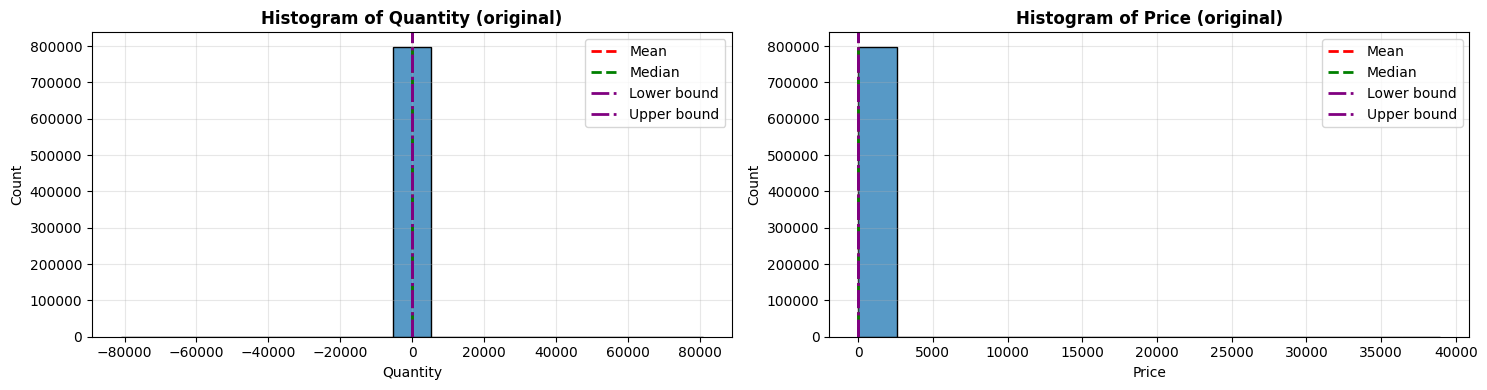

In [13]:
num_cols = ["Quantity", "Price"]
visualizations.distribution(df_copy, num_cols)

As it can be seen, both distributions are heavily affected by extreme values, as no difference can be appreciated between the mean, meadian (Q2), and lower and upper bound of the IQR. Instead of removing the data outside the IQR boundaries, let's observe the distribution applyting a tranformation that allow us to visualize positive and non-positive values, since the logarithmic scaling doesn't work with non-positive values, and the `MinMaxScaler` and `StandardScaler` don't change the way the values are distributed.

The following transformation will be applied (only to visualize the data):
$$x_{transformed​}=sign(x)⋅log(1+∣x∣)$$

- **`sign(x)`** returns:
  - `+1` if \( x > 0 \), `0` if \( x = 0 \), `-1` if \( x < 0 \)

- **Why this form?**
  - Standard log cannot handle **negative values or zero**
  - \( \log(1 + |x|) \) ensures all inputs are valid and reduces skewness
  - `sign(x)` restores the original positive/negative direction

- **What problem does it solve?**
  - Allows transforming data with **negatives and zeros**
  - Keeps the distribution shape interpretable for visualization

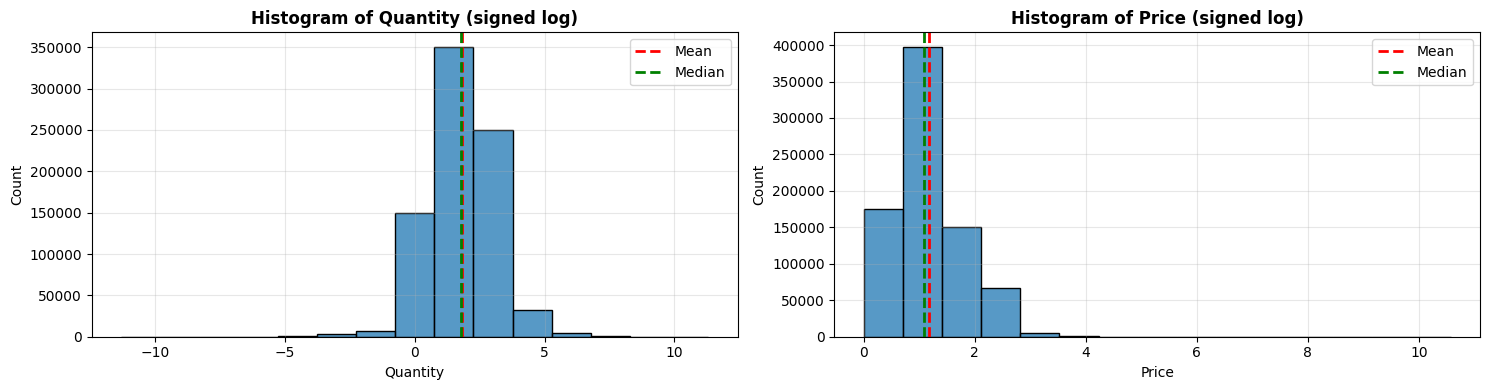

In [14]:
visualizations.distribution(df_copy, num_cols, scale=True)

With the data scaled, both distributions can be easily observed. If the IQR process would have been applied to treat the outliers, we would had lost a large portion of the dataset. For future steps involving predictive modelling with machine learning algorithms, we must recall that the data must be scaled before training the models.

### **Visualizations**

Before proceeding with the visualizations, some feature engineering will be done.

In [15]:
# Time features Year, Month, Quarter and Weekday
df_copy["Year"] = df_copy["InvoiceDate"].dt.year
df_copy["Month"] = df_copy["InvoiceDate"].dt.month
df_copy["Quarter"] = df_copy["InvoiceDate"].dt.quarter
df_copy["Weekday"] = df_copy["InvoiceDate"].dt.day_name()

# Total price of the product quantity x price
df_copy["TotalPrice"] = df_copy["Quantity"] * df_copy["Price"]

**Country**

c:\Users\HP\Desktop\Master\6. ML_DL\ML_Project\notebooks\../src\visualizations.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels([f"{x*100:.1f}%" for x in axes[0,1].get_xticks()])


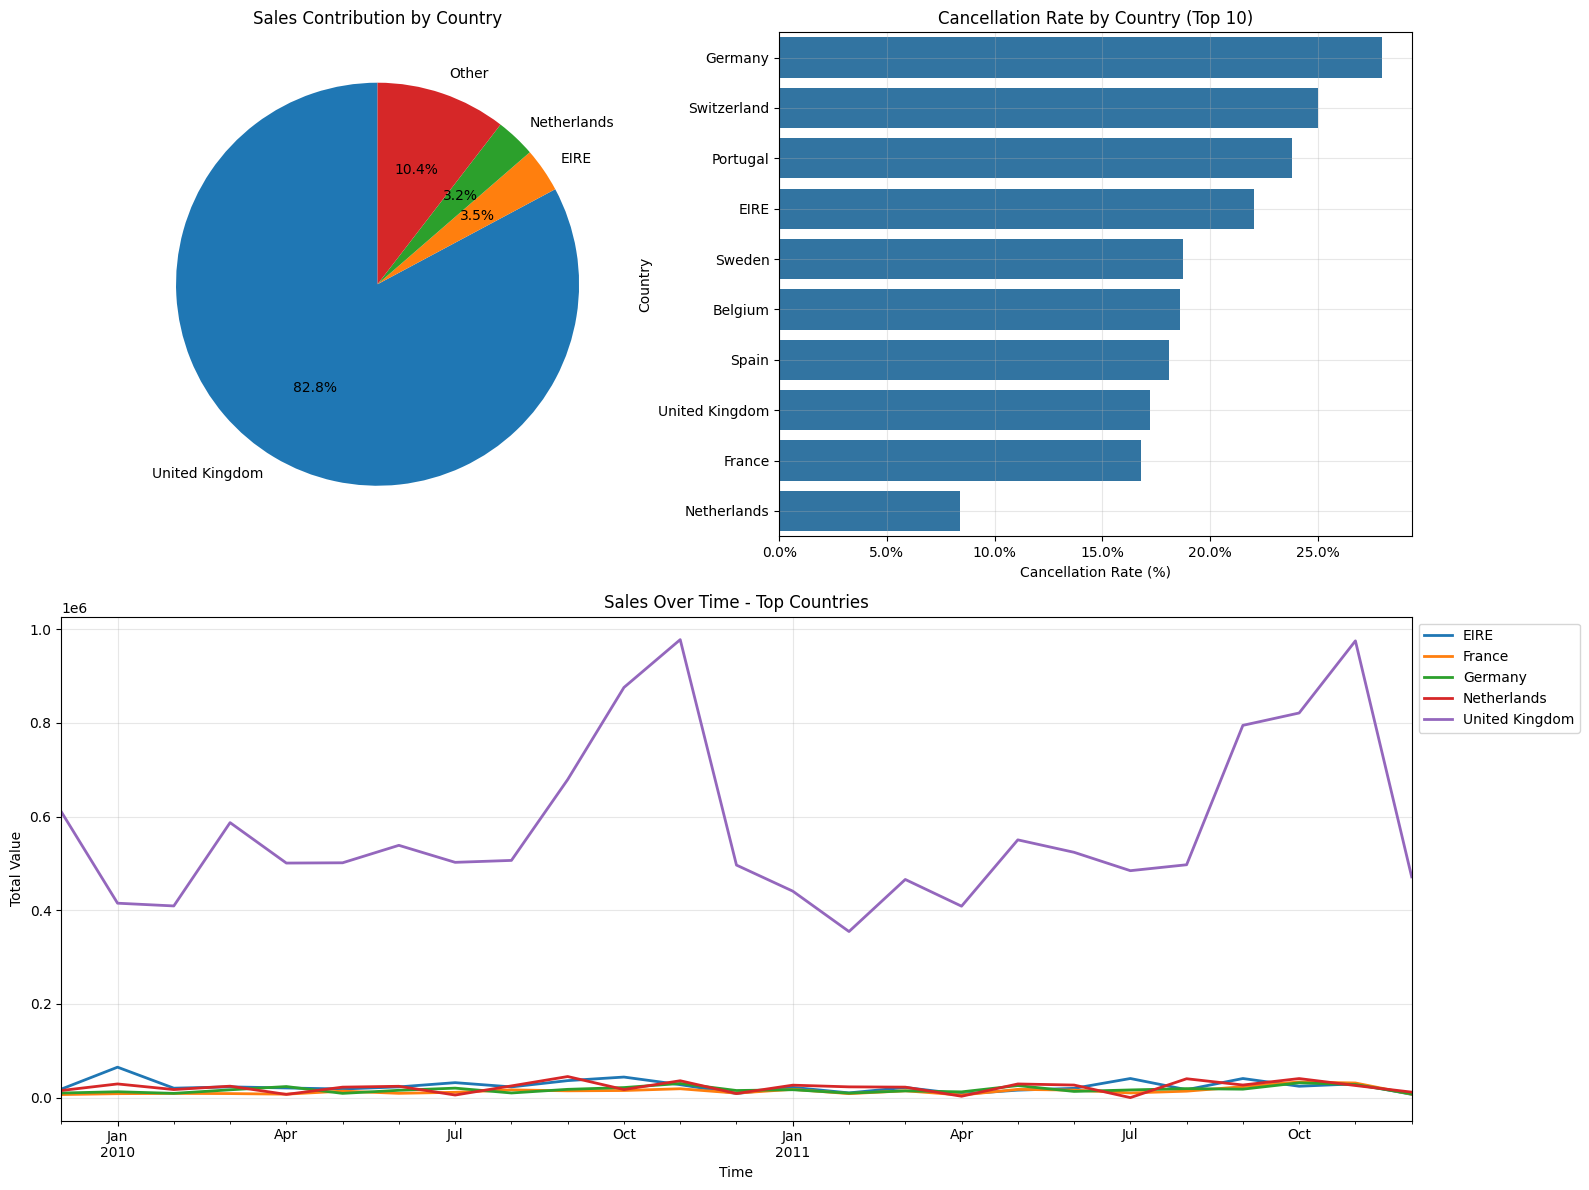

In [16]:
visualizations.country(df_copy)

From both, the piechart and the lineplot, can be derived that the customers in the United Kingdom (same country our company is located in) are almost the totally of the income, with a 82.8% of total sales contribution. Related to this matter, the lineplot gives us more information realted with the seasonality of the sales, highlighting the increase of sales from August to Novemberi both 2010 and 2011.

From the sidebar chart, are displayed the countries that have a higher rate of cancellations with respect to their number of unique invoices.

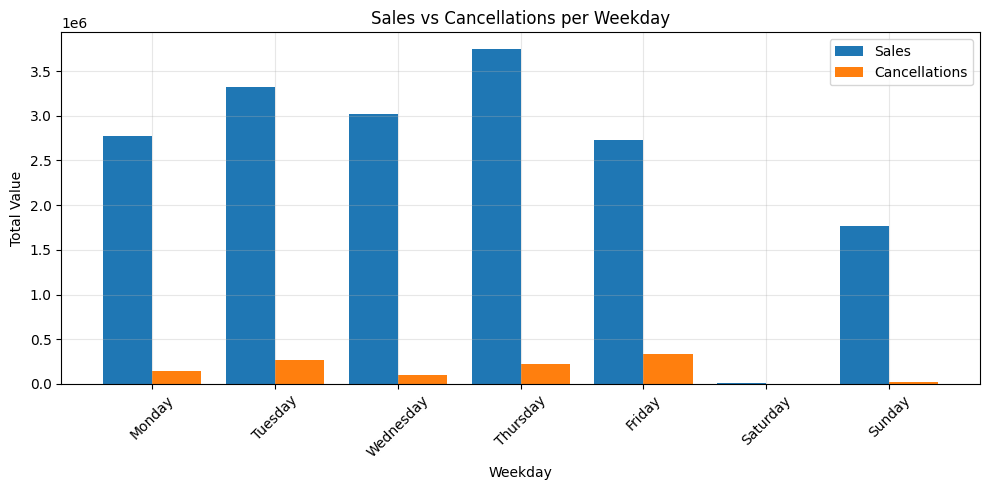

In [17]:
visualizations.weekday(df_copy)

Since a montlhy seasonality has been spotted in the previous visualization, here we can see if there's any pattern in sales/cancellations with respect the weekday. Despite the decrease in sales and cancellations at the weekend, no other significant pattern can be derived.

**Sales per Product**

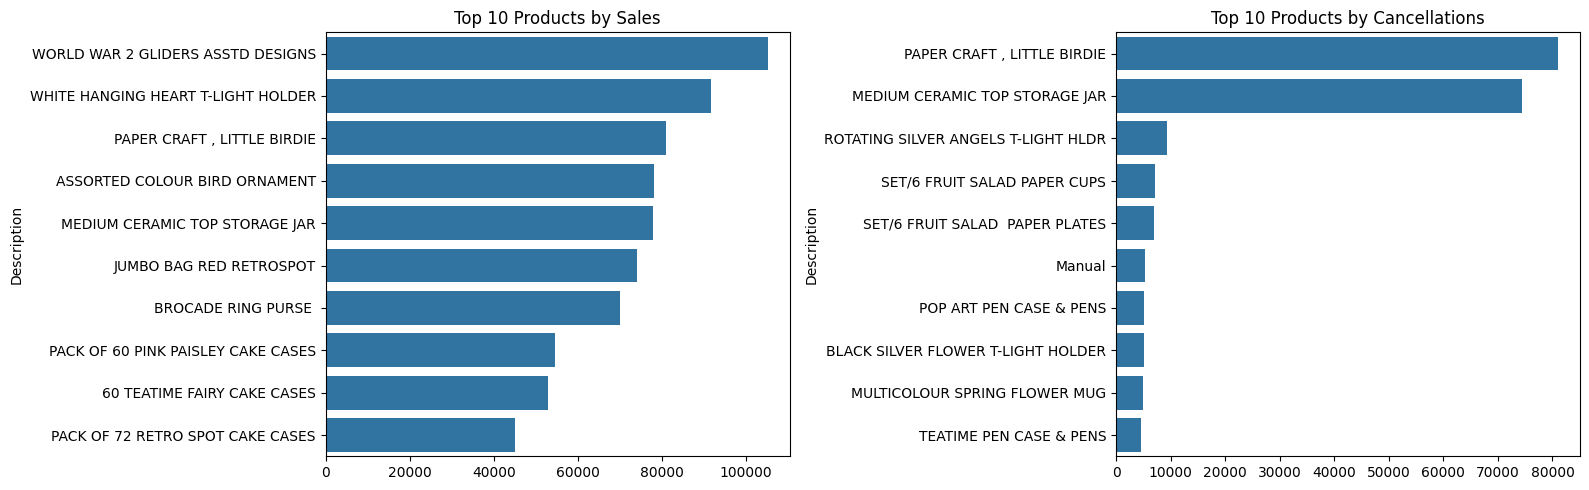

In [18]:
# Aggregate
product_sales = df_copy[df_copy["Quantity"] > 0].groupby("Description")["Quantity"].sum().sort_values(ascending=False)
product_cancellations = df_copy[df_copy["Quantity"] < 0].groupby("Description")["Quantity"].sum().abs().sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=product_sales.values[:10], y=product_sales.index[:10], ax=axes[0])
axes[0].set_title("Top 10 Products by Sales")

sns.barplot(x=product_cancellations.values[:10], y=product_cancellations.index[:10], ax=axes[1])
axes[1].set_title("Top 10 Products by Cancellations")

plt.tight_layout()
plt.show()

#### **Customer Analysis**

In [19]:
customer_df = df_copy[df_copy["Cancellation"] == 0].groupby("Customer ID").agg({
    "Invoice": "nunique",          # number of orders
    "Quantity": "sum",               # total items bought
    "TotalPrice": "sum",             # total money spent
    "InvoiceDate": ["min", "max"]    # first & last purchase
})

# Flatten columns
customer_df.columns = ["NumOrders", "TotalQuantity", "TotalSpent", "FirstPurchase", "LastPurchase"]

customer_df.head()

,NumOrders,TotalQuantity,TotalSpent,FirstPurchase,LastPurchase
Customer ID,,,,,
12346,12,74285,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00
12347,8,2967,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00
12348,5,2714,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00
12349,4,1624,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00
12350,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


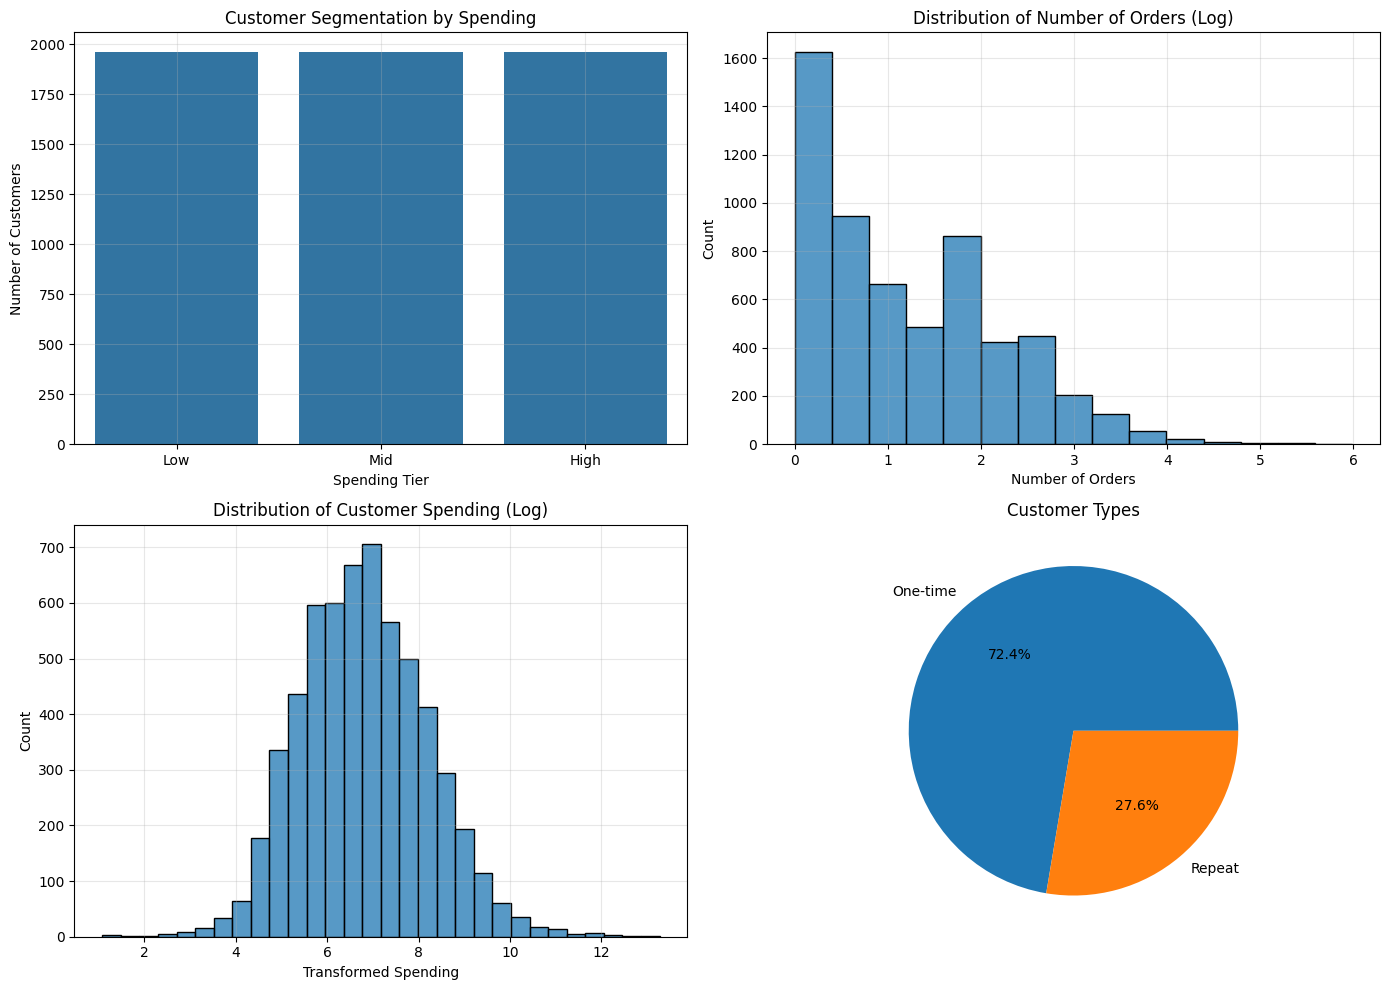

In [28]:
visualizations.customer(customer_df)

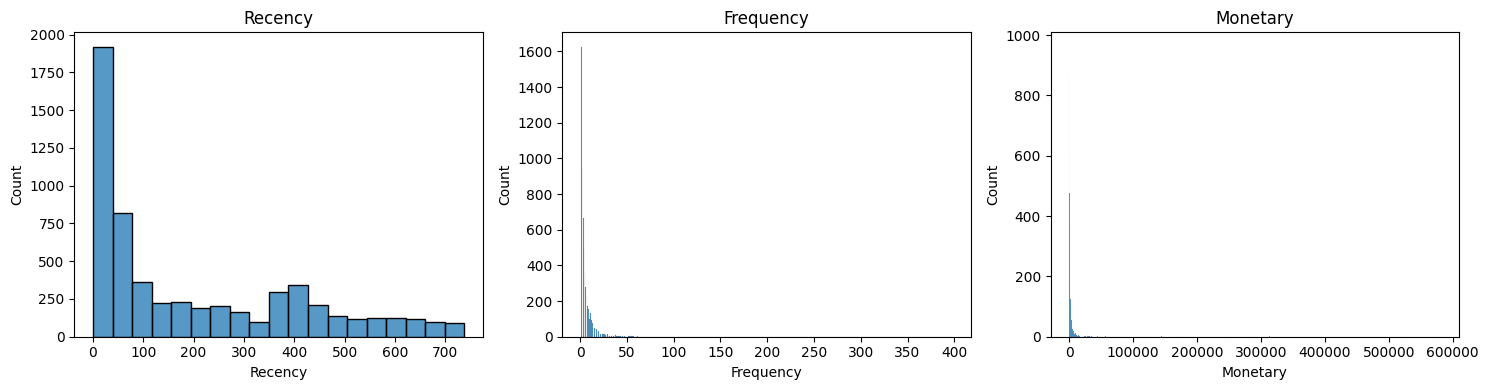

In [29]:
snapshot_date = df_copy["InvoiceDate"].max()

rfm = df_copy[df_copy["Quantity"] > 0].groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Invoice": "nunique",                                  # Frequency
    "TotalPrice": "sum"                                      # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

WITH CANCELLATIONSSSSSSSSSSSSS

In [32]:
df_sales = df_copy[df_copy["Quantity"] > 0]

snapshot_date = df_copy["InvoiceDate"].max()

rfm = df_sales.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

##############

df_cancel = df_copy[df_copy["Quantity"] < 0]

cancel_features = df_cancel.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).abs()

cancel_features.columns = ["NumCancellations", "CancelValue"]

########
rfm = rfm.merge(cancel_features, how="left", on="Customer ID")
rfm = rfm.fillna(0)

######
rfm["CancelRate"] = rfm["NumCancellations"] / (rfm["Frequency"] + 1)
rfm["CancelValueRatio"] = rfm["CancelValue"] / (rfm["Monetary"] + 1)

## **Feature Engineering: Customer-Level Features**

In this project, we shift from transaction-level data to a **customer-level perspective**, since our goal is to predict customer behavior (e.g., whether a customer is likely to purchase again).

To achieve this, we aggregate transactional data and construct meaningful features that describe each customer's behavior.

---

**Why Customer-Level Features?**

Each row in the dataset represents a transaction, but:
- A single customer can have multiple transactions
- Behavioral patterns emerge only when we **aggregate activity per customer**

Therefore, we build a dataset where:
- Each row = one customer
- Each column = a behavioral feature

---

**RFM Features**

We begin with the classic **RFM framework**:

- **Recency (R)**: How recently the customer made a purchase  
- **Frequency (F)**: How often the customer purchases  
- **Monetary (M)**: How much the customer spends  

These are widely used in customer analytics because they capture:
- Engagement (Recency)
- Loyalty (Frequency)
- Value (Monetary)


In [ ]:
# Keep only valid purchases
df_sales = df_copy[df_copy["Quantity"] > 0]

# Reference date (last date in dataset)
snapshot_date = df_copy["InvoiceDate"].max()

# Build RFM
rfm = df_sales.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Invoice": "nunique",                                     # Frequency
    "TotalPrice": "sum"                                       # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

#### Incorporating Cancellations

Cancellations provide important information about customer behavior:
- Returns may indicate dissatisfaction
- High cancellation rates may signal unreliable or low-quality customers

Instead of mixing cancellations into RFM (which would distort it), we model them separately.

In [ ]:
# Cancellation data
df_cancel = df_copy[df_copy["Quantity"] < 0]

cancel_features = df_cancel.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).abs()

cancel_features.columns = ["NumCancellations", "CancelValue"]

#### Merging Customer Features

We combine RFM features with cancellation behavior to create a more complete customer profile.

In [ ]:
rfm = rfm.merge(cancel_features, how="left", on="Customer ID")
rfm = rfm.fillna(0)

#### Derived Features (Behavioral Ratios)

We create additional features to better capture customer quality:

- **CancelRate**: Proportion of cancelled orders relative to purchases  
- **CancelValueRatio**: Share of money lost due to cancellations  

These features are especially useful for distinguishing:
- Loyal customers vs risky customers

In [ ]:
rfm["CancelRate"] = rfm["NumCancellations"] / (rfm["Frequency"] + 1)
rfm["CancelValueRatio"] = rfm["CancelValue"] / (rfm["Monetary"] + 1)

rfm.head()

### Final Feature Set

Each customer is now represented by:

- Recency
- Frequency
- Monetary
- Number of cancellations
- Cancellation value
- Cancellation rate
- Cancellation value ratio

This forms the input dataset for modeling.

---

## 🤖 Modeling Approach

### Supervised vs Unsupervised Learning

At this stage, we consider two possible approaches:

---

### 1. Supervised Learning (Recommended)

If we define a target variable such as:
- "Will the customer purchase again?"

Then we can train a model to **predict future behavior**.

Examples:
- Logistic Regression
- Random Forest
- Gradient Boosting

👉 This is the preferred approach because:
- It directly answers the business question
- It allows measurable performance (accuracy, recall, etc.)

---

### 2. Unsupervised Learning

If no target variable is defined, we can:
- Segment customers into groups (clustering)

Examples:
- K-Means
- Hierarchical clustering

👉 This helps:
- Identify customer segments (high value, low value, risky)
- Understand patterns without prediction

---

### Final Decision

In this project, we follow a **supervised learning approach**, because:

- The goal is to **predict customer behavior**
- We want to identify customers likely to:
  - Purchase again
  - Churn

The engineered features (RFM + cancellations) will be used as input for this predictive model.

# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


## 4. Estadísticas descriptivas
df.describe()

## 5. Visualizaciones

In [ ]:
### importante gestionarla visualizacion cuando hay outliers 

## 6. Agrupación por cliente (Customer ID)

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. Con Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

